In [1]:
import sys

sys.path.append("../")

import scipy
import optuna

import numpy as np
import pandas as pd

from docplex.mp.model import Model
from qiskit.circuit import ClassicalRegister, ParameterVector, QuantumCircuit, QuantumRegister
from qiskit.primitives import BackendEstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import from_docplex_mp
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz
from utils import objective_scipy, ObjectiveOptuna

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
simulator = AerSimulator(method="statevector", device="GPU")
estimator = BackendEstimatorV2(backend=simulator)
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

In [3]:
assets_data = pd.read_csv(filepath_or_buffer="../datasets/sp500_assets_close_price.csv", index_col=0)

In [4]:
tickers = np.random.choice(assets_data.columns, size=10, replace=False)

In [5]:
assets_close_price = assets_data[tickers]

In [6]:
assets_pct_change = assets_close_price.pct_change().dropna()

In [7]:
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [8]:
q = 0.5
b = 3
return_risk_free = 0.0375
weights_array = np.array([1/b for _ in range(len(tickers))])

## Equality constraint

In [9]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
model.add_constraint(x.sum() == b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);

minimize
 - 0.150577 x(0) - 0.026679 x(1) - 0.010436 x(2) + 0.071307 x(3)
 + 0.111346 x(4) - 0.020029 x(5) - 0.051407 x(6) + 0.003756 x(7)
 - 0.054498 x(8) + 0.110816 x(9) [ 0.000315 x(0)^2 + 0.000328 x(0)*x(1)
 + 0.000020 x(0)*x(2) + 0.000056 x(0)*x(3) + 0.000020 x(0)*x(4)
 - 0.000014 x(0)*x(5) - 0.000020 x(0)*x(6) + 0.000097 x(0)*x(7)
 + 0.000078 x(0)*x(8) + 0.000106 x(0)*x(9) + 0.002022 x(1)^2
 + 0.000001 x(1)*x(2) + 0.000310 x(1)*x(3) + 0.000013 x(1)*x(4)
 - 0.000199 x(1)*x(5) + 0.000009 x(1)*x(6) + 0.000216 x(1)*x(7)
 + 0.000193 x(1)*x(8) + 0.000322 x(1)*x(9) + 0.000189 x(2)^2
 + 0.000258 x(2)*x(3) + 0.000074 x(2)*x(4) + 0.000264 x(2)*x(5)
 + 0.000099 x(2)*x(6) + 0.000049 x(2)*x(7) + 0.000085 x(2)*x(8)
 

In [11]:
result = model.solve()

In [12]:
result.objective_value

-0.21815556901922142

In [13]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [14]:
result_array

array([1., 0., 0., 0., 0., 0., 1., 0., 1., 0.])

In [15]:
quad_model = from_docplex_mp(model=model)
print(quad_model.prettyprint())

Problem name: combinatorial_portfolio_optimization

Minimize
  0.00031472200011272236*x(0)^2 + 0.0003277613800520766*x(0)*x(1)
  + 1.9729451317658383e-05*x(0)*x(2) + 5.6132880418294405e-05*x(0)*x(3)
  + 2.0312443310380976e-05*x(0)*x(4) - 1.4423150806079798e-05*x(0)*x(5)
  - 2.0469251483833514e-05*x(0)*x(6) + 9.691580024129528e-05*x(0)*x(7)
  + 7.806394657970282e-05*x(0)*x(8) + 0.00010581460692554984*x(0)*x(9)
  + 0.002021582017625215*x(1)^2 + 8.288464804759117e-07*x(1)*x(2)
  + 0.0003100482939371236*x(1)*x(3) + 1.3340985485115637e-05*x(1)*x(4)
  - 0.00019906816332472245*x(1)*x(5) + 9.372965774323032e-06*x(1)*x(6)
  + 0.00021598712633677*x(1)*x(7) + 0.00019278784070415393*x(1)*x(8)
  + 0.00032236700795296413*x(1)*x(9) + 0.00018872318610817994*x(2)^2
  + 0.00025801498880771695*x(2)*x(3) + 7.433145701906345e-05*x(2)*x(4)
  + 0.00026384514546432073*x(2)*x(5) + 9.877017934685278e-05*x(2)*x(6)
  + 4.927559165661725e-05*x(2)*x(7) + 8.480853321036268e-05*x(2)*x(8)
  + 9.798130934079367e-05*x(2

In [16]:
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
print(qubo.prettyprint())

Problem name: 

Minimize
  0.00031472200111272235*x(0)^2 + 0.0003277613820520766*x(0)*x(1)
  + 1.972945331765838e-05*x(0)*x(2) + 5.6132882418294404e-05*x(0)*x(3)
  + 2.0312445310380975e-05*x(0)*x(4) - 1.4423148806079798e-05*x(0)*x(5)
  - 2.0469249483833515e-05*x(0)*x(6) + 9.691580224129529e-05*x(0)*x(7)
  + 7.806394857970282e-05*x(0)*x(8) + 0.00010581460892554985*x(0)*x(9)
  + 0.002021582018625215*x(1)^2 + 8.288484804759116e-07*x(1)*x(2)
  + 0.0003100482959371236*x(1)*x(3) + 1.3340987485115638e-05*x(1)*x(4)
  - 0.00019906816132472246*x(1)*x(5) + 9.372967774323032e-06*x(1)*x(6)
  + 0.00021598712833676998*x(1)*x(7) + 0.00019278784270415392*x(1)*x(8)
  + 0.0003223670099529641*x(1)*x(9) + 0.00018872318710817993*x(2)^2
  + 0.00025801499080771695*x(2)*x(3) + 7.433145901906346e-05*x(2)*x(4)
  + 0.0002638451474643207*x(2)*x(5) + 9.877018134685278e-05*x(2)*x(6)
  + 4.927559365661725e-05*x(2)*x(7) + 8.480853521036269e-05*x(2)*x(8)
  + 9.798131134079368e-05*x(2)*x(9) + 0.0006210436270154562*x(3)^

In [17]:
ising, offset = qubo.to_ising()

In [18]:
ising

SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII', 'IIIIIIIIZZ', 'IIIIIIIZIZ', 'IIIIIIZIIZ', 'IIIIIZIIIZ', 'IIIIZIIIIZ', 'IIIZIIIIIZ', 'IIZIIIIIIZ', 'IZIIIIIIIZ', 'ZIIIIIIIIZ', 'IIIIIIIZZI', 'IIIIIIZIZI', 'IIIIIZIIZI', 'IIIIZIIIZI', 'IIIZIIIIZI', 'IIZIIIIIZI', 'IZIIIIIIZI', 'ZIIIIIIIZI', 'IIIIIIZZII', 'IIIIIZIZII', 'IIIIZIIZII', 'IIIZIIIZII', 'IIZIIIIZII', 'IZIIIIIZII', 'ZIIIIIIZII', 'IIIIIZZIII', 'IIIIZIZIII', 'IIIZIIZIII', 'IIZIIIZIII', 'IZIIIIZIII', 'ZIIIIIZIII', 'IIIIZZIIII', 'IIIZIZIIII', 'IIZIIZIIII', 'IZIIIZIIII', 'ZIIIIZIIII', 'IIIZZIIIII', 'IIZIZIIIII', 'IZIIZIIIII', 'ZIIIZIIIII', 'IIZZIIIIII', 'IZIZIIIIII', 'ZIIZIIIIII', 'IZZIIIIIII', 'ZIZIIIIIII', 'ZZIIIIIIII'],
              coeffs=[ 7.49634797e-02+0.j,  1.20302171e-02+0.j,  4.88679418e-03+0.j,
 -3.62891635e-02+0.j, -5.61273168e-02+0.j,  9.83808976e-03+0.j,
  2.54870264e-02+0.j, -2.16067464e-03+0.j,  2.69025927e-02+0.j,
 

In [19]:
offset

np.float64(0.03288945482324331)

In [20]:
qc = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=b, measurement=False)

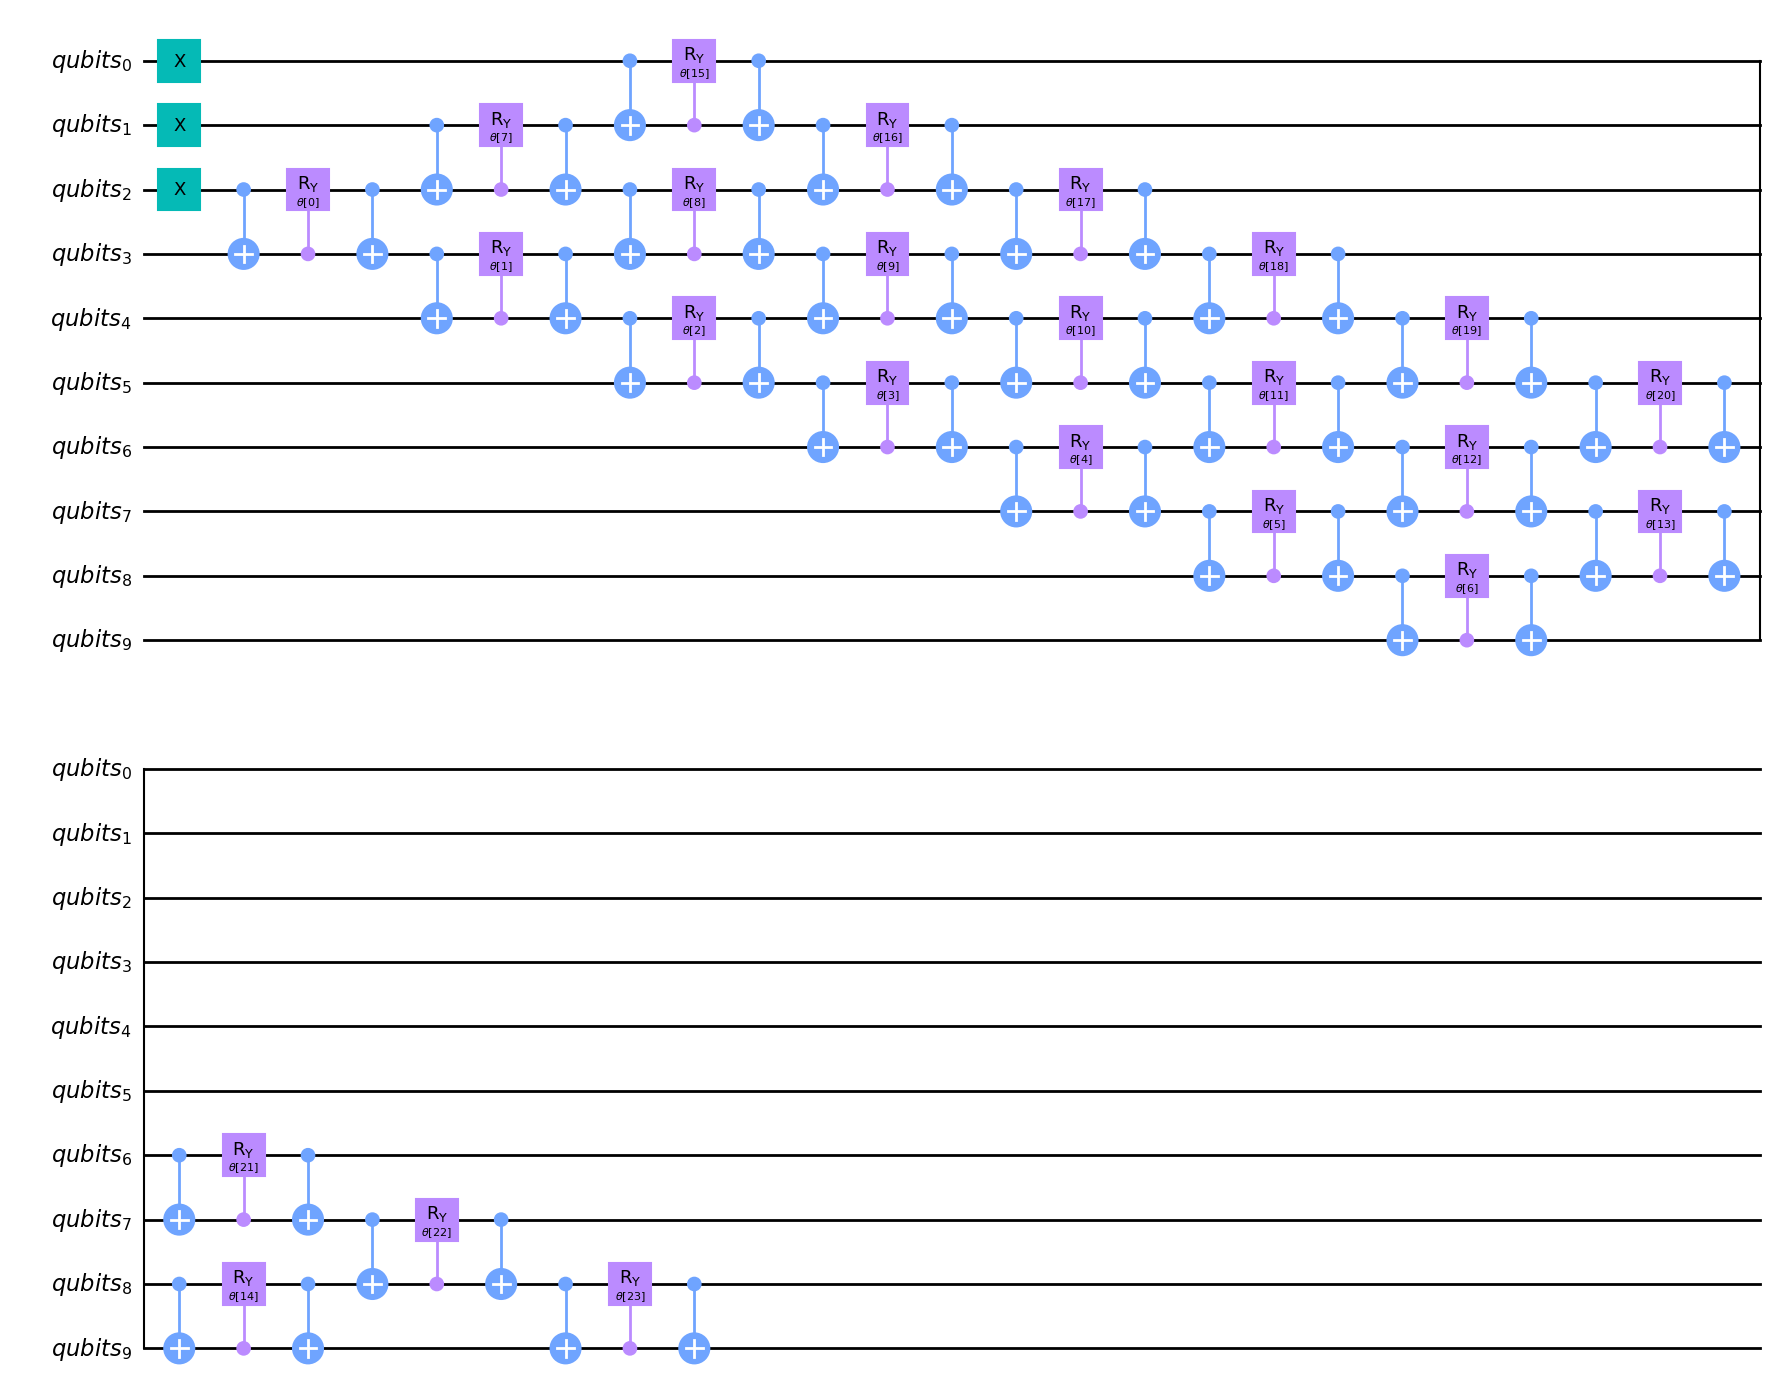

In [21]:
qc.draw(output="mpl", style="clifford")

In [22]:
x0 = 4*np.pi*np.random.random(size=qc.num_parameters)
bounds = [(0, 4*np.pi) for _ in range(x0.shape[0])]
result = scipy.optimize.minimize(fun=objective_scipy, x0=x0, method="cobyla", bounds=bounds, args=(estimator, qc, ising, offset))

In [23]:
result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.18830637823483903
       x: [ 1.230e+01  1.880e+00 ...  9.054e+00  2.980e-03]
    nfev: 258
   maxcv: 0.0

In [24]:
ansatz = qc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

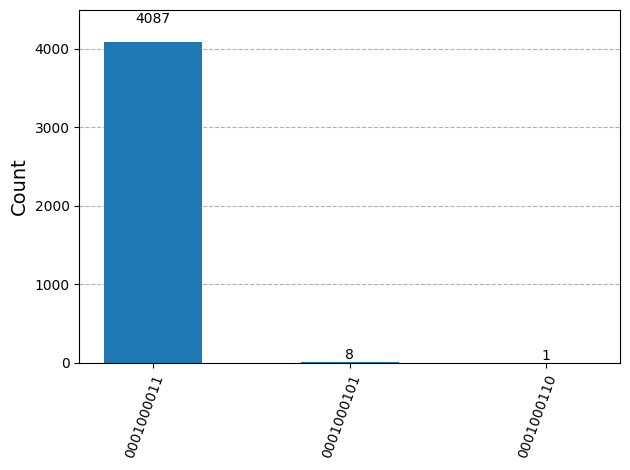

In [25]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [26]:
objective_optuna = ObjectiveOptuna(qc=qc, estimator=estimator, ising=ising, offset=offset)

In [27]:
sampler = optuna.samplers.CmaEsSampler()
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

[I 2026-05-04 21:45:33,287] A new study created in memory with name: no-name-982e3720-046a-4a44-9b07-3939a97e636e
[I 2026-05-04 21:45:33,300] Trial 0 finished with value: -0.1209255699519658 and parameters: {'x[0]': 11.512884292453355, 'x[1]': 11.75960558690527, 'x[2]': 6.009781388191719, 'x[3]': 1.1935391249260852, 'x[4]': 2.910656230768105, 'x[5]': 3.9958007502142983, 'x[6]': 11.296333238786847, 'x[7]': 7.290460425495143, 'x[8]': 0.1609063403060234, 'x[9]': 1.9992168614667165, 'x[10]': 6.026915225763741, 'x[11]': 8.083027062078738, 'x[12]': 5.526808329365209, 'x[13]': 6.626215319625858, 'x[14]': 6.008263769216186, 'x[15]': 8.976067973084268, 'x[16]': 4.698296983205776, 'x[17]': 3.9731671636972705, 'x[18]': 0.04017992664170605, 'x[19]': 8.070906148870995, 'x[20]': 6.86977532190092, 'x[21]': 2.440938346464252, 'x[22]': 6.194952286567376, 'x[23]': 2.334151054554493}. Best is trial 0 with value: -0.1209255699519658.
[I 2026-05-04 21:45:33,485] Trial 1 finished with value: 0.0098842368871

In [28]:
study.best_value

-0.18741233634490925

In [29]:
ansatz = qc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

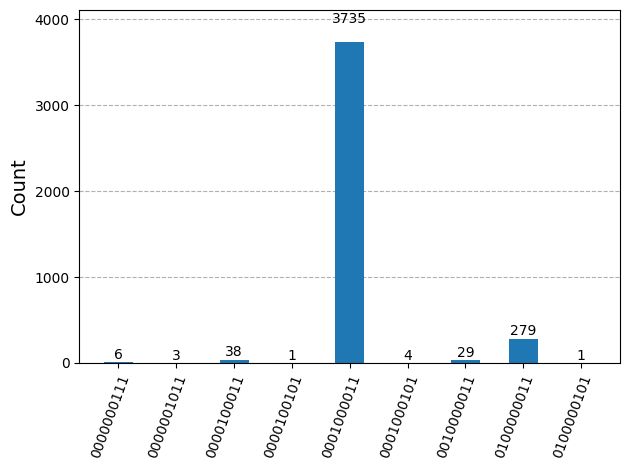

In [30]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

## Inequality constraint

In [31]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
model.add_constraint(x.sum() <= b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);

minimize
 - 0.150577 x(0) - 0.026679 x(1) - 0.010436 x(2) + 0.071307 x(3)
 + 0.111346 x(4) - 0.020029 x(5) - 0.051407 x(6) + 0.003756 x(7)
 - 0.054498 x(8) + 0.110816 x(9) [ 0.000315 x(0)^2 + 0.000328 x(0)*x(1)
 + 0.000020 x(0)*x(2) + 0.000056 x(0)*x(3) + 0.000020 x(0)*x(4)
 - 0.000014 x(0)*x(5) - 0.000020 x(0)*x(6) + 0.000097 x(0)*x(7)
 + 0.000078 x(0)*x(8) + 0.000106 x(0)*x(9) + 0.002022 x(1)^2
 + 0.000001 x(1)*x(2) + 0.000310 x(1)*x(3) + 0.000013 x(1)*x(4)
 - 0.000199 x(1)*x(5) + 0.000009 x(1)*x(6) + 0.000216 x(1)*x(7)
 + 0.000193 x(1)*x(8) + 0.000322 x(1)*x(9) + 0.000189 x(2)^2
 + 0.000258 x(2)*x(3) + 0.000074 x(2)*x(4) + 0.000264 x(2)*x(5)
 + 0.000099 x(2)*x(6) + 0.000049 x(2)*x(7) + 0.000085 x(2)*x(8)
 

In [32]:
result = model.solve()

In [33]:
result.objective_value

-0.21815556901922148

In [34]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [35]:
result_array

array([1., 0., 0., 0., 0., 0., 1., 0., 1., 0.])

In [36]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
# model.add_constraint(x.sum() <= b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);

minimize
 - 0.150577 x(0) - 0.026679 x(1) - 0.010436 x(2) + 0.071307 x(3)
 + 0.111346 x(4) - 0.020029 x(5) - 0.051407 x(6) + 0.003756 x(7)
 - 0.054498 x(8) + 0.110816 x(9) [ 0.000315 x(0)^2 + 0.000328 x(0)*x(1)
 + 0.000020 x(0)*x(2) + 0.000056 x(0)*x(3) + 0.000020 x(0)*x(4)
 - 0.000014 x(0)*x(5) - 0.000020 x(0)*x(6) + 0.000097 x(0)*x(7)
 + 0.000078 x(0)*x(8) + 0.000106 x(0)*x(9) + 0.002022 x(1)^2
 + 0.000001 x(1)*x(2) + 0.000310 x(1)*x(3) + 0.000013 x(1)*x(4)
 - 0.000199 x(1)*x(5) + 0.000009 x(1)*x(6) + 0.000216 x(1)*x(7)
 + 0.000193 x(1)*x(8) + 0.000322 x(1)*x(9) + 0.000189 x(2)^2
 + 0.000258 x(2)*x(3) + 0.000074 x(2)*x(4) + 0.000264 x(2)*x(5)
 + 0.000099 x(2)*x(6) + 0.000049 x(2)*x(7) + 0.000085 x(2)*x(8)
 

In [37]:
quad_model = from_docplex_mp(model=model)
print(quad_model.prettyprint())

Problem name: combinatorial_portfolio_optimization

Minimize
  0.00031472200011272236*x(0)^2 + 0.0003277613800520766*x(0)*x(1)
  + 1.9729451317658383e-05*x(0)*x(2) + 5.6132880418294405e-05*x(0)*x(3)
  + 2.0312443310380976e-05*x(0)*x(4) - 1.4423150806079798e-05*x(0)*x(5)
  - 2.0469251483833514e-05*x(0)*x(6) + 9.691580024129528e-05*x(0)*x(7)
  + 7.806394657970282e-05*x(0)*x(8) + 0.00010581460692554984*x(0)*x(9)
  + 0.002021582017625215*x(1)^2 + 8.288464804759117e-07*x(1)*x(2)
  + 0.0003100482939371236*x(1)*x(3) + 1.3340985485115637e-05*x(1)*x(4)
  - 0.00019906816332472245*x(1)*x(5) + 9.372965774323032e-06*x(1)*x(6)
  + 0.00021598712633677*x(1)*x(7) + 0.00019278784070415393*x(1)*x(8)
  + 0.00032236700795296413*x(1)*x(9) + 0.00018872318610817994*x(2)^2
  + 0.00025801498880771695*x(2)*x(3) + 7.433145701906345e-05*x(2)*x(4)
  + 0.00026384514546432073*x(2)*x(5) + 9.877017934685278e-05*x(2)*x(6)
  + 4.927559165661725e-05*x(2)*x(7) + 8.480853321036268e-05*x(2)*x(8)
  + 9.798130934079367e-05*x(2

In [38]:
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
print(qubo.prettyprint())

Problem name: 

Minimize
  0.00031472200011272236*x(0)^2 + 0.0003277613800520766*x(0)*x(1)
  + 1.9729451317658383e-05*x(0)*x(2) + 5.6132880418294405e-05*x(0)*x(3)
  + 2.0312443310380976e-05*x(0)*x(4) - 1.4423150806079798e-05*x(0)*x(5)
  - 2.0469251483833514e-05*x(0)*x(6) + 9.691580024129528e-05*x(0)*x(7)
  + 7.806394657970282e-05*x(0)*x(8) + 0.00010581460692554984*x(0)*x(9)
  + 0.002021582017625215*x(1)^2 + 8.288464804759117e-07*x(1)*x(2)
  + 0.0003100482939371236*x(1)*x(3) + 1.3340985485115637e-05*x(1)*x(4)
  - 0.00019906816332472245*x(1)*x(5) + 9.372965774323032e-06*x(1)*x(6)
  + 0.00021598712633677*x(1)*x(7) + 0.00019278784070415393*x(1)*x(8)
  + 0.00032236700795296413*x(1)*x(9) + 0.00018872318610817994*x(2)^2
  + 0.00025801498880771695*x(2)*x(3) + 7.433145701906345e-05*x(2)*x(4)
  + 0.00026384514546432073*x(2)*x(5) + 9.877017934685278e-05*x(2)*x(6)
  + 4.927559165661725e-05*x(2)*x(7) + 8.480853321036268e-05*x(2)*x(8)
  + 9.798130934079367e-05*x(2)*x(9) + 0.0006210436260154562*x(3)^

In [39]:
ising, offset = qubo.to_ising()

In [40]:
identity = SparsePauliOp(data="II", coeffs=[1])
ising_expanded = ising.tensor(other=identity)

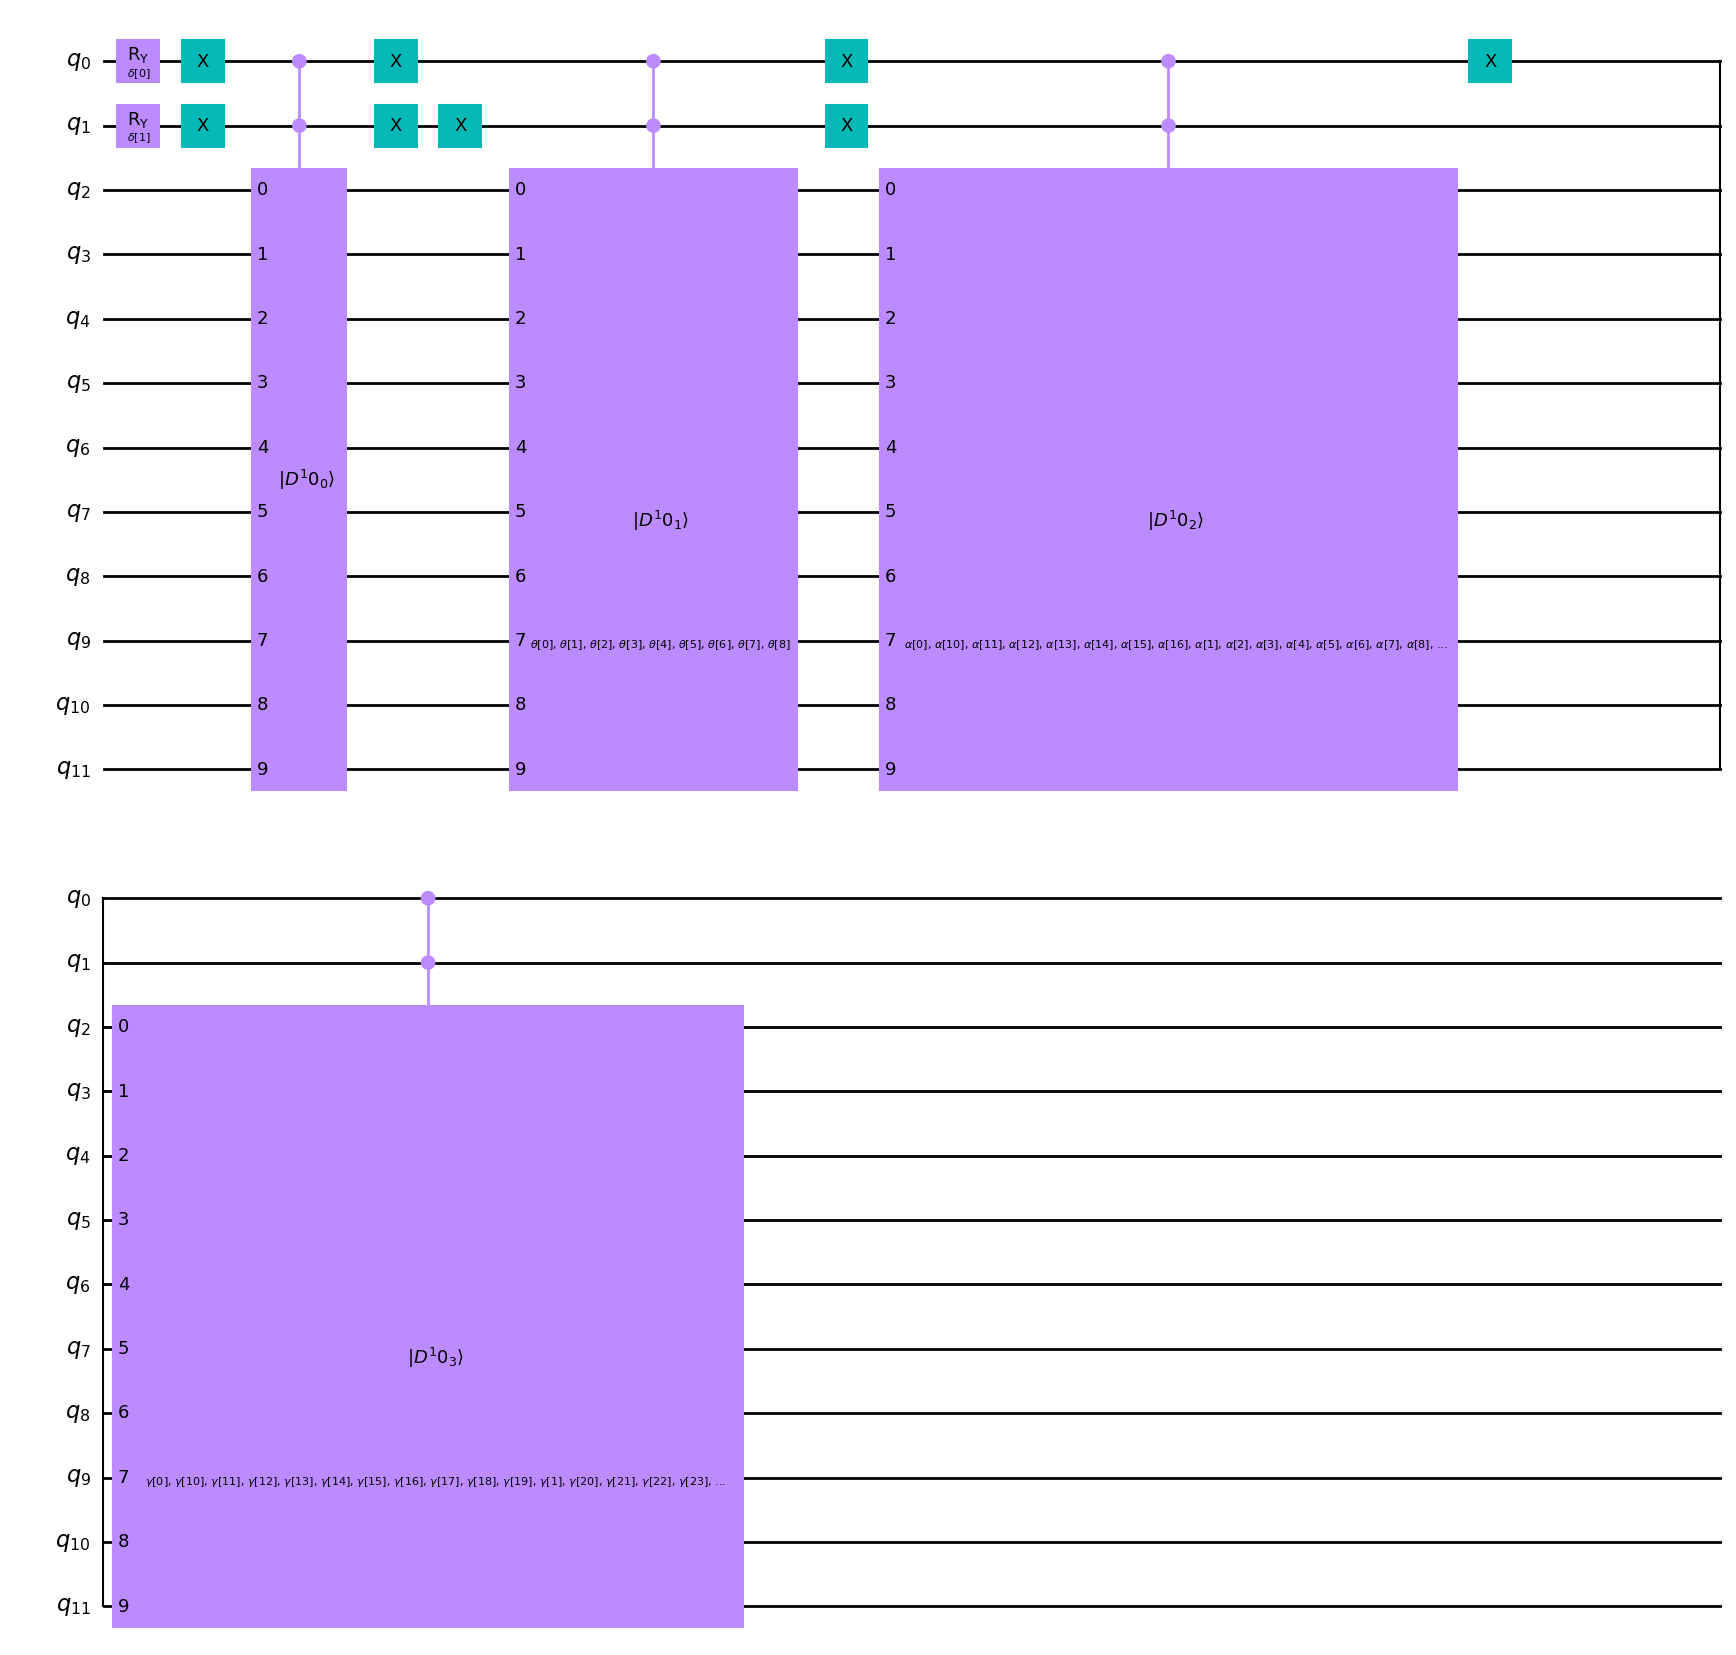

In [41]:
qubits = QuantumRegister(size=ising_expanded.num_qubits, name="q")
params_vec = ParameterVector(name=r"$\delta$", length=ising_expanded.num_qubits-ising.num_qubits)

qc = QuantumCircuit(qubits)
for idx, param in enumerate(params_vec):
    qc.ry(theta=param, qubit=qubits[idx])

params_names = {0: "", 1: "theta", 2: "alpha", 3: "gamma"}

for k in range(4):
    dicke = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=k, measurement=False, param_name=params_names[k])
    if k == 0:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 1:
        qc.x(qubit=qubits[1])
    elif k == 2:
        qc.x(qubit=qubits[0])
    dicke_gate = dicke.to_gate(label=rf"$\vert D^{len(tickers)}_{k} \rangle$").control(2)
    qc.append(dicke_gate, qargs=range(qubits.size))
    if k == 0:
        qc.x(qubit=qubits[[i for i in range(ising_expanded.num_qubits-ising.num_qubits)]])
    elif k == 1:
        qc.x(qubit=qubits[1])
    elif k == 2:
        qc.x(qubit=qubits[0])

qc.draw(output="mpl", style="clifford")

In [42]:
tqc = pm.run(qc)

In [43]:
x0 = 4*np.pi*np.random.random(size=qc.num_parameters)
bounds = [(0, 4*np.pi) for _ in range(x0.shape[0])]
result = scipy.optimize.minimize(fun=objective_scipy, x0=x0, method="cobyla", bounds=bounds, args=(estimator, tqc, ising_expanded, offset))

In [44]:
result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.13709126446949588
       x: [ 1.036e+01  5.962e+00 ...  1.772e+00  8.584e+00]
    nfev: 470
   maxcv: 0.0

In [45]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

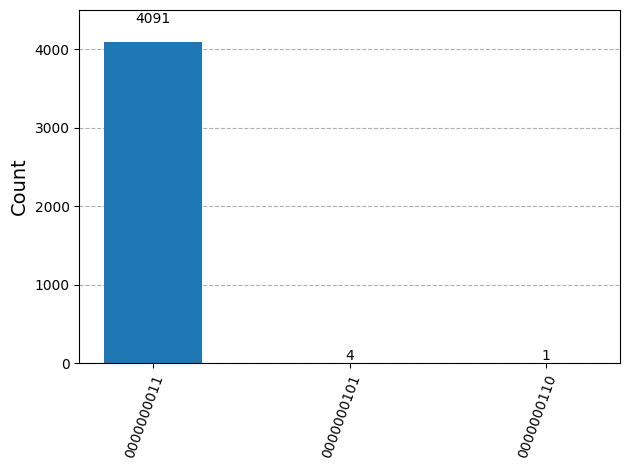

In [46]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [47]:
objective_optuna = ObjectiveOptuna(qc=tqc, estimator=estimator, ising=ising_expanded, offset=offset)

In [48]:
sampler = optuna.samplers.CmaEsSampler()
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

[I 2026-05-04 21:48:01,088] A new study created in memory with name: no-name-6d298680-21fe-41aa-8632-45a7362c6f0b
[I 2026-05-04 21:48:01,129] Trial 0 finished with value: 0.011079652935160514 and parameters: {'x[0]': 8.353139559033917, 'x[1]': 8.270313749110707, 'x[2]': 6.946398176644804, 'x[3]': 4.03188794043124, 'x[4]': 2.4487937658273435, 'x[5]': 2.752168361891211, 'x[6]': 6.186247868669503, 'x[7]': 9.180602489013207, 'x[8]': 9.260348400800048, 'x[9]': 10.074660801774936, 'x[10]': 1.3530335080323175, 'x[11]': 1.461161821509141, 'x[12]': 0.9965383965484769, 'x[13]': 0.7646794714075372, 'x[14]': 6.271955707329669, 'x[15]': 10.20286839931524, 'x[16]': 8.675921771987399, 'x[17]': 11.281084621626636, 'x[18]': 9.70855392757603, 'x[19]': 8.01958148527261, 'x[20]': 2.6827745350645293, 'x[21]': 5.273734810827805, 'x[22]': 1.363881492660723, 'x[23]': 10.872800634324548, 'x[24]': 9.982859429709192, 'x[25]': 10.413622101747617, 'x[26]': 7.057325906579354, 'x[27]': 9.555837723316923, 'x[28]': 6.

In [49]:
study.best_value

-0.1663134359787961

In [50]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

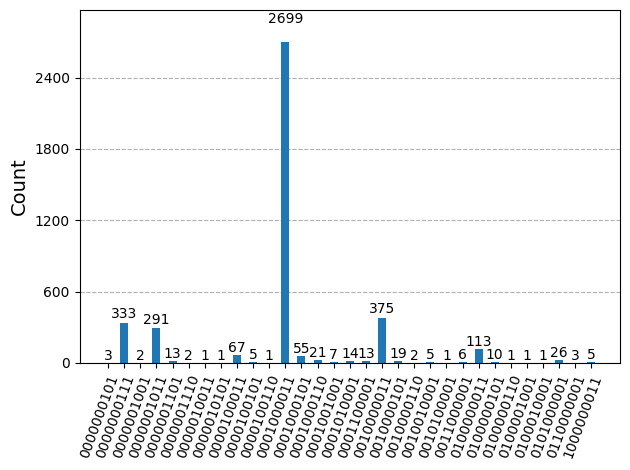

In [51]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)